## Stage 0: Scaffold

Repository layout, pinned requirements, README skeleton, and smoke tests.

## Stage 1a: History (SPY, VIX, IRX)

Download and freeze SPY, ^VIX, and ^IRX daily closes with a manifest.

## Stage 1b: Chain collection

Run the chain collector on 3 to 5 market days and freeze the snapshot.

## Stage 2a: Black-Scholes pricing and Greeks

Implement Black-76 pricing and spot Greeks; verify against DESIGN.md acceptance values.

## Stage 5a: Hedging engine

Implement the delta-hedging simulation and verify on synthetic GBM paths.

## Stage 5b: Real-data hedging study

Run the hedging study on real SPY paths; produce Figures 6 to 8 and Table 4.

The study delta-hedges a 30-day at-the-money call bought at the VIX on every trading day, following DESIGN.md section 3. It reads only the frozen history, so it reruns without a download. P&L and predictors are fractions of the premium carried to expiry (C0·G0), shown in percent.

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedLocator, NullLocator, ScalarFormatter

from volsurf import hedging as hg
from volsurf.black_scholes import bs_vega
from volsurf.data import load_history

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
FIGURES = ROOT / "figures"

H_VALUES = [1, 2, 3, 5, 7, 10, 21]  # rebalance interval in trading days
C_BP = [0, 1, 5, 25, 100]  # cost in bp of notional traded
PREDICTORS = ["P_gap", "P_price", "P_path", "P_step"]
BLOCK, N_RESAMPLES, SEED_BOOT = 42, 2000, 20260930  # moving block bootstrap
N_PATHS, SEED_GBM = 100, 20261001  # GBM paths per real window; windows of n steps use seed [SEED_GBM, n]
SEEDS_TEXTBOOK = [(20261100 + k, 20261200 + k) for k in range(40)]  # section 3 set, 40 seed pairs
APRIL_2025 = ("2025-04-03", "2025-04-09")
STRIDE = 22  # non-overlapping subsamples: windows k, k + 22, k + 44, ... for each offset k

# Chart style: recessive grid and axes, ink for text, series colours for marks only.
INK, INK_2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
COST_COLOURS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # one blue, light to dark with cost
COST_MARKERS = ["o", "s", "^", "D", "v"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 9, "axes.titlesize": 10, "figure.titlesize": 11, "legend.frameon": False,
    "lines.linewidth": 2, "lines.markersize": 5,
})


def save(fig, name):
    """Save a figure to figures/ at 200 dpi and print its repository-relative path."""
    path = FIGURES / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved {path.relative_to(ROOT).as_posix()}")


def predictors(res, rows=slice(None)):
    """The three predictors of a HedgeResult, optionally restricted to some windows."""
    return {name: getattr(res, name.lower())[rows] for name in PREDICTORS}


history = load_history()
dates = history.index
S, r = history["spy"].to_numpy(), history["r"].to_numpy()
win = hg.study_windows(history)
steps = win.ends - win.starts
start_dates = dates[win.starts]
print(f"History: {dates[0].date()} to {dates[-1].date()}, {dates.size} closes")
print(
    f"Windows: {win.starts.size}, starting {start_dates[0].date()} to {start_dates[-1].date()}; "
    f"{steps.min()} to {steps.max()} trading-day steps; T0 from {win.T0.min() * 365:.0f} "
    f"to {win.T0.max() * 365:.0f} calendar days"
)

History: 2021-06-01 to 2026-09-29, 1339 closes
Windows: 1232, starting 2021-10-01 to 2026-08-28; 17 to 22 trading-day steps; T0 from 27 to 30 calendar days


In [2]:
results = {
    (h, c): hg.simulate_windows(S, win.t, r, win.starts, win.ends, win.sigma_i, win.K, h, c * 1e-4)
    for h in H_VALUES
    for c in C_BP
}
base = results[(1, 0)]  # daily hedging, no costs
n_by_h = {h: results[(h, 0)].n_intervals for h in H_VALUES}
print("Hedge intervals N per window: mean (min to max)")
for h in H_VALUES:
    print(f"  h = {h:>2}: {n_by_h[h].mean():5.2f} ({n_by_h[h].min()} to {n_by_h[h].max()})")

Hedge intervals N per window: mean (min to max)
  h =  1: 20.58 (17 to 22)
  h =  2: 10.55 (9 to 11)
  h =  3:  7.17 (6 to 8)
  h =  5:  4.58 (4 to 5)
  h =  7:  3.20 (3 to 4)
  h = 10:  2.58 (2 to 3)
  h = 21:  1.20 (1 to 2)


## Figure 7: implied against realised volatility
VIX at each window start against the realised volatility of that window, sigma_r = √(RV/T0), where RV sums squared daily log returns. The share of windows whose implied total variance exceeds the realised one does not depend on h or c, so it is reported once.

Share of windows with sigma_i^2*T0 > RV: 84.3% of 1232
Mean sigma_i (VIX): 19.18%; mean realised vol sigma_r: 15.78%
Mean total variance over a window: implied 0.00319, realised 0.00246
Saved figures/fig7_vix_vs_realised_vol.png


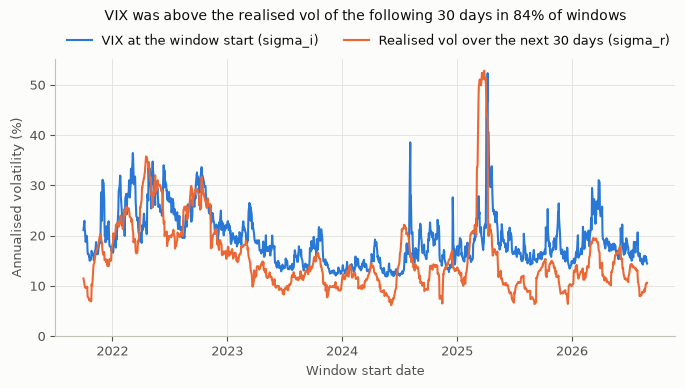

In [3]:
implied_var, rv = win.sigma_i**2 * win.T0, base.rv
sigma_r = np.sqrt(rv / win.T0)
share_implied_above = np.mean(implied_var > rv)
print(f"Share of windows with sigma_i^2*T0 > RV: {share_implied_above:.1%} of {rv.size}")
print(f"Mean sigma_i (VIX): {win.sigma_i.mean():.2%}; mean realised vol sigma_r: {sigma_r.mean():.2%}")
print(f"Mean total variance over a window: implied {implied_var.mean():.5f}, realised {rv.mean():.5f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(start_dates, 100 * win.sigma_i, color=BLUE, lw=1.5, label="VIX at the window start (sigma_i)")
ax.plot(start_dates, 100 * sigma_r, color=ORANGE, lw=1.5, label="Realised vol over the next 30 days (sigma_r)")
ax.set_xlabel("Window start date")
ax.set_ylabel("Annualised volatility (%)")
ax.set_ylim(bottom=0)
ax.set_title(
    f"VIX was above the realised vol of the following 30 days in {share_implied_above:.0%} of windows",
    pad=28,
)
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=2)
save(fig, "fig7_vix_vs_realised_vol.png")
plt.show()

## Table 4b: the R² ladder at c = 0
The ladder has four rungs: P_gap (the vol gap), P_price (the option repriced at the realised vol minus its premium, the exact expected P&L under GBM, so the step from P_gap isolates P_gap's functional form), P_path (the path's own gamma) and P_step (the timing of each move against gamma). R²_45 is measured about the 45 degree line, the OLS R² next to it ignores intercept and slope, and the slope comes from OLS of P&L on each predictor. Intervals are 95% moving block bootstrap percentiles over windows in start-date order. The GBM benchmark hedges 100 GBM paths on each real window's calendar and rates, with sigma_true set to that window's realised vol and sigma_i to its VIX, and pools every path. The April 2025 rows drop every window with a close from 2025-04-03 to 2025-04-09 and resample the remaining sequence; the benchmark is shown with and without the paths of those windows, so each real sample has a like-for-like benchmark.

In [4]:
april = hg.windows_containing(dates, win.starts, win.ends, *APRIL_2025)
keep = ~april
boot_full = hg.block_bootstrap_indices(win.starts.size, BLOCK, N_RESAMPLES, SEED_BOOT)
boot_keep = hg.block_bootstrap_indices(int(keep.sum()), BLOCK, N_RESAMPLES, SEED_BOOT)
print(
    f"April 2025 exclusion: {april.sum()} windows removed (starts {start_dates[april][0].date()} "
    f"to {start_dates[april][-1].date()}), {keep.sum()} kept"
)

gbm_benchmark = {
    h: hg.simulate_gbm_windows(win.t, r, win.starts, win.ends, sigma_r, win.sigma_i, h, 0.0, N_PATHS, SEED_GBM)
    for h in H_VALUES
}
ladders = {}
for h in H_VALUES:
    res, bench = results[(h, 0)], gbm_benchmark[h]
    ladders[("Full sample", h)] = hg.r2_ladder(res.pnl, predictors(res), boot_full)
    ladders[("GBM benchmark", h)] = hg.r2_ladder(
        bench.pnl.ravel(), {k: v.ravel() for k, v in predictors(bench).items()}
    )
    ladders[("Excluding April 2025", h)] = hg.r2_ladder(res.pnl[keep], predictors(res, keep), boot_keep)
    ladders[("GBM benchmark excluding April 2025", h)] = hg.r2_ladder(
        bench.pnl[keep].ravel(), {k: v[keep].ravel() for k, v in predictors(bench).items()}
    )
table_4b = pd.concat(ladders, names=["sample", "h", "predictor"])
with pd.option_context("display.max_rows", 200, "display.float_format", "{:.3f}".format):
    display(table_4b)

April 2025 exclusion: 27 windows removed (starts 2025-03-04 to 2025-04-09), 1205 kept


n  r2_45  r2_lo  r2_hi  \
sample                             h  predictor                                
Full sample                        1  P_gap        1232 -0.199 -1.124  0.643   
                                      P_price      1232  0.584  0.496  0.688   
                                      P_path       1232  0.671  0.472  0.847   
                                      P_step       1232  0.941  0.919  0.956   
GBM benchmark                      1  P_gap      123200  0.572    NaN    NaN   
                                      P_price    123200  0.808    NaN    NaN   
                                      P_path     123200  0.923    NaN    NaN   
                                      P_step     123200  0.963    NaN    NaN   
Excluding April 2025               1  P_gap        1205  0.592  0.512  0.665   
                                      P_price      1205  0.606  0.501  0.696   
                                      P_path       1205  0.830  0.788  0.858   
                                      P_step       1205  0.942  0.914  0.959   
GBM benchmark excluding April 2025 1  P_gap      120500  0.744    NaN    NaN   
                                      P_price    120500  0.808    NaN    NaN   
                                      P_path     120500  0.921    NaN    NaN   
                                      P_step     120500  0.971    NaN    NaN   
Full sample                        2  P_gap        1232 -0.066 -0.701  0.481   
                                      P_price      1232  0.459  0.324  0.547   
                                      P_path       1232  0.462  0.254  0.647   
                                      P_step       1232  0.800  0.629  0.931   
GBM benchmark                      2  P_gap      123200  0.484    NaN    NaN   
                                      P_price    123200  0.696    NaN    NaN   
                                      P_path     123200  0.768    NaN    NaN   
                                      P_step     123200  0.931    NaN    NaN   
Excluding April 2025               2  P_gap        1205  0.413  0.294  0.500   
                                      P_price      1205  0.410  0.266  0.527   
                                      P_path       1205  0.597  0.493  0.668   
                                      P_step       1205  0.905  0.858  0.936   
GBM benchmark excluding April 2025 2  P_gap      120500  0.605    NaN    NaN   
                                      P_price    120500  0.657    NaN    NaN   
                                      P_path     120500  0.744    NaN    NaN   
                                      P_step     120500  0.948    NaN    NaN   
Full sample                        3  P_gap        1232 -0.081 -0.668  0.395   
                                      P_price      1232  0.369  0.226  0.465   
                                      P_path       1232  0.404  0.258  0.536   
                                      P_step       1232  0.853  0.788  0.912   
GBM benchmark                      3  P_gap      123200  0.433    NaN    NaN   
                                      P_price    123200  0.619    NaN    NaN   
                                      P_path     123200  0.656    NaN    NaN   
                                      P_step     123200  0.904    NaN    NaN   
Excluding April 2025               3  P_gap        1205  0.325  0.203  0.417   
                                      P_price      1205  0.318  0.174  0.437   
                                      P_path       1205  0.479  0.372  0.554   
                                      P_step       1205  0.889  0.846  0.917   
GBM benchmark excluding April 2025 3  P_gap      120500  0.517    NaN    NaN   
                                      P_price    120500  0.559    NaN    NaN   
                                      P_path     120500  0.629    NaN    NaN   
                                      P_step     120500  0.924    NaN    NaN   
Full sample                        5  P_gap        123

## Table 4c: non-overlapping subsamples
Subsample k takes windows k, k + 22, k + 44, and so on, for each offset k from 0 to 21, so the 22 subsamples between them hold every window once. No window is longer than the stride, so windows 22 apart share no daily return, which stride_subsamples checks. The table gives the point estimates for offset 0 and the median and range across all 22.

In [5]:
subsamples = hg.stride_subsamples(win.starts, win.ends, STRIDE)  # raises if any two windows share a return
sizes = [sub.size for sub in subsamples]
covers_all = np.array_equal(np.sort(np.concatenate(subsamples)), np.arange(win.starts.size))
print(f"{len(subsamples)} subsamples at stride {STRIDE}, {min(sizes)} to {max(sizes)} windows each; "
      f"each window in exactly one: {covers_all}")
print(f"Longest window: {steps.max()} steps, no longer than the stride")
weekday_0 = pd.Series(start_dates[subsamples[0]].day_name()).value_counts()
print("Start weekdays of the offset-0 subsample: " + ", ".join(f"{d} {n}" for d, n in weekday_0.items()))
table_4c = pd.concat(
    {h: hg.stride_ladder(results[(h, 0)].pnl, predictors(results[(h, 0)]), subsamples) for h in H_VALUES},
    names=["h", "predictor"],
)
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
    display(table_4c)

22 subsamples at stride 22, 56 to 56 windows each; each window in exactly one: True
Longest window: 22 steps, no longer than the stride
Start weekdays of the offset-0 subsample: Friday 15, Wednesday 12, Tuesday 11, Monday 9, Thursday 9


n_offset0  r2_45_offset0  r2_45_median  r2_45_min  r2_45_max  \
h  predictor                                                                 
1  P_gap             56          0.382         0.277     -3.524      0.730   
   P_price           56          0.500         0.607     -0.023      0.790   
   P_path            56          0.528         0.659      0.185      0.883   
   P_step            56          0.883         0.946      0.845      0.981   
2  P_gap             56          0.156         0.042     -2.886      0.630   
   P_price           56          0.254         0.388     -0.140      0.710   
   P_path            56          0.334         0.378     -0.196      0.810   
   P_step            56          0.774         0.900     -0.676      0.964   
3  P_gap             56          0.012         0.065     -1.972      0.558   
   P_price           56          0.109         0.372     -0.133      0.593   
   P_path            56          0.143         0.429     -0.125      0.695   
   P_step            56          0.816         0.906      0.423      0.958   
5  P_gap             56          0.105        -0.581     -3.040      0.247   
   P_price           56          0.164         0.062     -0.718      0.384   
   P_path            56          0.220         0.128     -2.080      0.479   
   P_step            56          0.789         0.857      0.643      0.921   
7  P_gap             56          0.043         0.002     -1.538      0.320   
   P_price           56          0.080         0.181     -0.264      0.498   
   P_path            56          0.168         0.150     -0.552      0.546   
   P_step            56          0.600         0.854      0.600      0.884   
10 P_gap             56          0.137        -0.446     -1.302      0.450   
   P_price           56          0.161        -0.085     -0.391      0.499   
   P_path            56          0.227        -0.195     -0.833      0.514   
   P_step            56          0.744         0.817      0.744      0.880   
21 P_gap             56          0.117        -0.148     -0.691      0.229   
   P_price           56          0.119        -0.044     -0.325      0.193   
   P_path            56          0.128        -0.149     -0.686      0.228   
   P_step            56          0.791         0.806      0.764      0.843   

              r2_ols_offset0  r2_ols_median  r2_ols_min  r2_ols_max  \
h  predictor                                                          
1  P_gap               0.531          0.680       0.529       0.814   
   P_price             0.616          0.765       0.616       0.822   
   P_path              0.656          0.834       0.641       0.911   
   P_step              0.892          0.951       0.857       0.982   
2  P_gap               0.334          0.471       0.319       0.760   
   P_price             0.382          0.555       0.382       0.770   
   P_path              0.456          0.592       0.392       0.812   
   P_step              0.806          0.924       0.523       0.965   
3  P_gap               0.259          0.431       0.202       0.634   
   P_price             0.295          0.481       0.295       0.616   
   P_path              0.341          0.532       0.272       0.696   
   P_step              0.821          0.913       0.628       0.959   
5  P_gap               0.213          0.204       0.027       0.472   
   P_price             0.233          0.238       0.054       0.478   
   P_path              0.287          0.275       0.051       0.518   
   P_step              0.802          0.871       0.752       0.936   
7  P_gap               0.158          0.199       0.089       0.483   
   P_price             0.160          0.230       0.136       0.505   
   P_path              0.230          0.240       0.128       0.555   
   P_step              0.691          0.868       0.691       0.913   
10 P_gap               0.207          0.114       0.016       0.542   
   P_price             0.197          0.

## Figure 6: hedged P&L against the vol gap
Daily hedging without costs gives one point per window. The windows removed by the April 2025 exclusion are marked. The right panel repeats the plot for the step predictor, which weights each day's squared return by that day's gamma.

Saved figures/fig6_pnl_vs_vol_gap.png


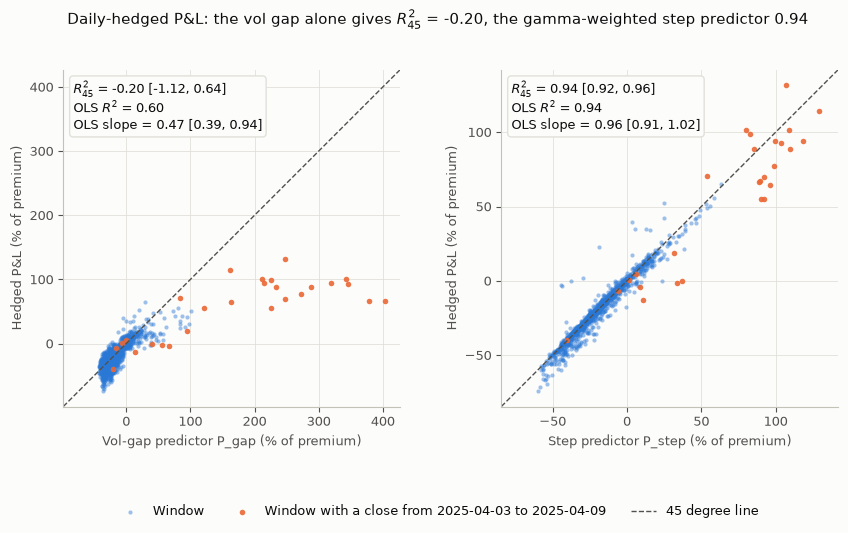

In [6]:
ladder_1 = ladders[("Full sample", 1)]
y = 100 * base.pnl
fig, axes = plt.subplots(1, 2, figsize=(10, 5.2))
for ax, name, label in zip(axes, ["P_gap", "P_step"], ["Vol-gap predictor P_gap", "Step predictor P_step"]):
    p = 100 * predictors(base)[name]
    row = ladder_1.loc[name]
    ax.scatter(p[keep], y[keep], s=9, color=BLUE, alpha=0.45, linewidths=0, label="Window")
    ax.scatter(p[april], y[april], s=16, color=ORANGE, alpha=0.9, linewidths=0,
               label="Window with a close from 2025-04-03 to 2025-04-09")
    lo, hi = min(p.min(), y.min()), max(p.max(), y.max())
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=INK_2, lw=1, ls="--", label="45 degree line")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal")  # equal scales, so the 45 degree line reads as one
    ax.text(
        0.03, 0.97,
        f"$R^2_{{45}}$ = {row.r2_45:.2f} [{row.r2_lo:.2f}, {row.r2_hi:.2f}]\n"
        f"OLS $R^2$ = {row.r2_ols:.2f}\n"
        f"OLS slope = {row.beta:.2f} [{row.beta_lo:.2f}, {row.beta_hi:.2f}]",
        transform=ax.transAxes, va="top", ha="left", color=INK,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "#fcfcfb", "edgecolor": GRID},
    )
    ax.set_xlabel(f"{label} (% of premium)")
    ax.set_ylabel("Hedged P&L (% of premium)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.2, wspace=0.3)
fig.suptitle(
    f"Daily-hedged P&L: the vol gap alone gives $R^2_{{45}}$ = {ladder_1.loc['P_gap', 'r2_45']:.2f}, "
    f"the gamma-weighted step predictor {ladder_1.loc['P_step', 'r2_45']:.2f}"
)
save(fig, "fig6_pnl_vs_vol_gap.png")
plt.show()

## Table 4a and Figure 8: hedging error
The hedging error is e = P&L - P_gap per window, and RMSE = √(mean² + std²) with the population std. N is the number of hedge intervals, which varies with window length. Figure 8 plots each h at its mean N, with bars from the minimum to the maximum N. The synthetic reference hedges 100 GBM paths on each real window's calendar with sigma_true = sigma_i at no cost and uses each path's own realised variance in P_gap. The dashed Derman-Kamal curve is the known-vol asymptote √(π/4)·vega0·sigma_i/(√N·C0), averaged over windows.

In [7]:
rows = []
for h in H_VALUES:
    n = n_by_h[h]
    for c in C_BP:
        res = results[(h, c)]
        stats = hg.hedging_error_stats(res.pnl, res.p_gap)
        rows.append({
            "h": h, "c (bp)": c, "mean N": n.mean(), "min N": n.min(), "max N": n.max(),
            "mean P&L (%)": 100 * res.pnl.mean(), "mean e (%)": 100 * stats["mean"],
            "std e (%)": 100 * stats["std"], "RMSE e (%)": 100 * stats["rmse"],
        })
table_4a = pd.DataFrame(rows).set_index(["h", "c (bp)"])
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.2f}".format):
    display(table_4a)

gbm_reference = {
    h: hg.simulate_gbm_windows(win.t, r, win.starts, win.ends, win.sigma_i, win.sigma_i, h, 0.0, N_PATHS, SEED_GBM)
    for h in H_VALUES
}
reference = pd.DataFrame(
    {h: {k: 100 * v for k, v in hg.hedging_error_stats(res.pnl, res.p_gap).items()} for h, res in gbm_reference.items()}
).T.rename_axis("h")
reference.insert(0, "mean N", [n_by_h[h].mean() for h in H_VALUES])
print("Synthetic reference (GBM on the real calendars, sigma_true = sigma_i, c = 0), % of premium:")
display(reference.round(2))
vega0 = bs_vega(S[win.starts], win.K, win.T0, r[win.starts], 0.0, win.sigma_i)
dk_scale = np.mean(vega0 * win.sigma_i / base.c0)  # Derman-Kamal curve is 100·dk_scale·√(π/4)/√N (%)
best_h = {c: table_4a.xs(c, level="c (bp)")["RMSE e (%)"].idxmin() for c in C_BP}
print(f"Derman-Kamal scale mean(vega0*sigma_i/C0) = {dk_scale:.4f}")
print("Lowest-RMSE h per cost level: " + ", ".join(f"{c} bp: h = {best_h[c]}" for c in C_BP))

mean N  min N  max N  mean P&L (%)  mean e (%)  std e (%)  \
h  c (bp)                                                              
1  0        20.58     17     22        -17.59       -5.38      25.43   
   1        20.58     17     22        -18.76       -6.55      25.40   
   5        20.58     17     22        -23.43      -11.23      25.33   
   25       20.58     17     22        -46.81      -34.61      26.30   
   100      20.58     17     22       -134.50     -122.29      43.33   
2  0        10.55      9     11        -17.12       -4.91      28.28   
   1        10.55      9     11        -18.11       -5.91      28.23   
   5        10.55      9     11        -22.08       -9.88      28.09   
   25       10.55      9     11        -41.95      -29.75      28.27   
   100      10.55      9     11       -116.46     -104.26      39.76   
3  0         7.17      6      8        -17.56       -5.36      30.86   
   1         7.17      6      8        -18.46       -6.26      30.80   
   5         7.17      6      8        -22.05       -9.85      30.61   
   25        7.17      6      8        -40.01      -27.81      30.35   
   100       7.17      6      8       -107.36      -95.16      39.01   
5  0         4.58      4      5        -18.92       -6.72      38.67   
   1         4.58      4      5        -19.70       -7.50      38.61   
   5         4.58      4      5        -22.81      -10.60      38.36   
   25        4.58      4      5        -38.33      -26.13      37.56   
   100       4.58      4      5        -96.55      -84.34      40.84   
7  0         3.20      3      4        -18.63       -6.42      39.50   
   1         3.20      3      4        -19.33       -7.13      39.44   
   5         3.20      3      4        -22.17       -9.96      39.24   
   25        3.20      3      4        -36.32      -24.11      38.54   
   100       3.20      3      4        -89.39      -77.19      40.90   
10 0         2.58      2      3        -20.16       -7.95      45.88   
   1         2.58      2      3        -20.80       -8.60      45.84   
   5         2.58      2      3        -23.38      -11.18      45.65   
   25        2.58      2      3        -36.26      -24.06      44.96   
   100       2.58      2      3        -84.57      -72.37      45.83   
21 0         1.20      1      2        -20.40       -8.19      59.89   
   1         1.20      1      2        -20.90       -8.70      59.89   
   5         1.20      1      2        -22.94      -10.74      59.87   
   25        1.20      1      2        -33.11      -20.91      59.83   
   100       1.20      1      2        -71.25      -59.05      60.54   

           RMSE e (%)  
h  c (bp)              
1  0            25.99  
   1            26.23  
   5            27.71  
   25           43.47  
   100         129.74  
2  0            28.70  
   1            28.84  
   5            29.78  
   25           41.04  
   100         111.58  
3  0            31.32  
   1            31.43  
   5            32.15  
   25           41.16  
   100         102.84  
5  0            39.25  
   1            39.33  
   5            39.80  
   25           45.75  
   100          93.71  
7  0            40.02  
   1            40.08  
   5            40.48  
   25           45.47  
   100          87.36  
10 0            46.57  
   1            46.64  
   5            47.00  
   25           50.99  
   100          85.66  
21 0            60.45  
   1            60.51  
   5            60.82  
   25           63.38  
   100          84.57

Synthetic reference (GBM on the real calendars, sigma_true = sigma_i, c = 0), % of premium:


,mean N,mean,std,rmse
h,,,,
1,20.58,0.09,11.03,11.03
2,10.55,0.13,20.40,20.40
3,7.17,0.13,26.29,26.29
5,4.58,0.21,35.51,35.51
7,3.20,-0.04,42.47,42.47
10,2.58,0.19,51.44,51.44
21,1.20,0.18,72.92,72.92


Derman-Kamal scale mean(vega0*sigma_i/C0) = 0.9997
Lowest-RMSE h per cost level: 0 bp: h = 1, 1 bp: h = 1, 5 bp: h = 1, 25 bp: h = 2, 100 bp: h = 21


Saved figures/fig8_hedging_error.png


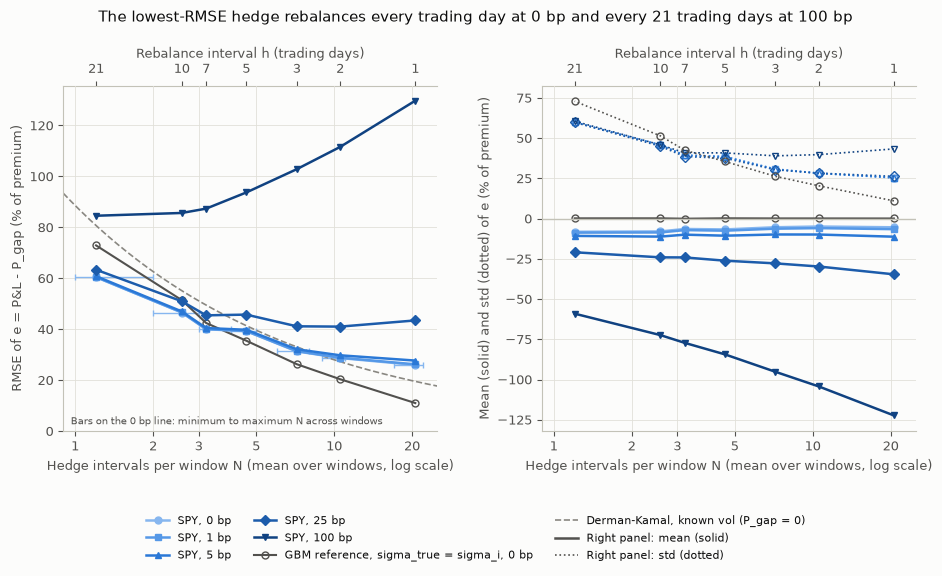

In [8]:
from matplotlib.lines import Line2D

mean_n = np.array([n_by_h[h].mean() for h in H_VALUES])
min_n = np.array([n_by_h[h].min() for h in H_VALUES])
max_n = np.array([n_by_h[h].max() for h in H_VALUES])
n_curve = np.geomspace(0.9, 25, 200)


def every(h):
    """'every trading day' or 'every h trading days'."""
    return "every trading day" if h == 1 else f"every {h} trading days"


fig, (ax_rmse, ax_ms) = plt.subplots(1, 2, figsize=(11, 5.4))
for c, colour, marker in zip(C_BP, COST_COLOURS, COST_MARKERS):
    stats = table_4a.xs(c, level="c (bp)")
    ax_rmse.errorbar(
        mean_n, stats["RMSE e (%)"], xerr=[mean_n - min_n, max_n - mean_n] if c == 0 else None,
        color=colour, marker=marker, lw=1.8, capsize=2, elinewidth=1,
    )
    ax_ms.plot(mean_n, stats["mean e (%)"], color=colour, marker=marker, lw=1.8)
    ax_ms.plot(mean_n, stats["std e (%)"], color=colour, marker=marker, lw=1.2, ls=":", mfc="none")
ax_rmse.plot(mean_n, reference["rmse"], color=INK_2, marker="o", mfc="none", lw=1.5)
ax_rmse.plot(n_curve, 100 * dk_scale * np.sqrt(np.pi / 4) / np.sqrt(n_curve), color=MUTED, ls="--", lw=1.2)
ax_rmse.text(0.02, 0.02, "Bars on the 0 bp line: minimum to maximum N across windows",
             transform=ax_rmse.transAxes, fontsize=7.5, color=INK_2)
ax_ms.plot(mean_n, reference["mean"], color=INK_2, marker="o", mfc="none", lw=1.5)
ax_ms.plot(mean_n, reference["std"], color=INK_2, marker="o", mfc="none", lw=1.2, ls=":")
ax_ms.axhline(0, color=AXIS, lw=1)
for ax in (ax_rmse, ax_ms):
    ax.set_xscale("log")
    ax.set_xlim(0.9, 25)
    ax.xaxis.set_major_locator(FixedLocator([1, 2, 3, 5, 10, 20]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("Hedge intervals per window N (mean over windows, log scale)")
    top = ax.secondary_xaxis("top")
    top.set_xticks(mean_n, labels=[str(h) for h in H_VALUES])
    top.xaxis.set_minor_locator(NullLocator())
    top.set_xlabel("Rebalance interval h (trading days)")
ax_rmse.set_ylabel("RMSE of e = P&L - P_gap (% of premium)")
ax_ms.set_ylabel("Mean (solid) and std (dotted) of e (% of premium)")
ax_rmse.set_ylim(bottom=0)

handles = [
    Line2D([], [], color=colour, marker=marker, lw=1.8, label=f"SPY, {c} bp")
    for c, colour, marker in zip(C_BP, COST_COLOURS, COST_MARKERS)
] + [
    Line2D([], [], color=INK_2, marker="o", mfc="none", lw=1.5, label="GBM reference, sigma_true = sigma_i, 0 bp"),
    Line2D([], [], color=MUTED, ls="--", lw=1.2, label="Derman-Kamal, known vol (P_gap = 0)"),
    Line2D([], [], color=INK_2, lw=1.8, label="Right panel: mean (solid)"),
    Line2D([], [], color=INK_2, lw=1.2, ls=":", label="Right panel: std (dotted)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=8)
fig.subplots_adjust(bottom=0.24, wspace=0.28)
fig.suptitle(
    f"The lowest-RMSE hedge rebalances {every(best_h[0])} at 0 bp and {every(best_h[100])} at 100 bp",
    y=1.02,
)
save(fig, "fig8_hedging_error.png")
plt.show()

## Weekday diagnostic of P_step residuals
Under daily hedging without costs, each interval's hedged P&L minus its P_step term is grouped by the weekday of the interval's closing day. Monday intervals span the weekend: P_step charges three calendar days of sigma_i² there, against roughly one trading day of realised variance. Means are per interval in percent of premium, with 95% moving block bootstrap intervals from the full-sample resamples. η² is the share of residual variance that the weekday means explain.

In [9]:
weekday_table, eta2 = hg.weekday_diagnostic(
    base.interval_pnl, base.interval_p_step, dates, win.starts, win.ends, 1, boot_full
)
shown = weekday_table.copy()
for col in ["pnl", "p_step", "residual", "residual_lo", "residual_hi"]:
    shown[col] = 100 * shown[col]
shown = shown.rename(columns={
    "calendar_days": "mean calendar days", "pnl": "mean P&L (%)", "p_step": "mean P_step (%)",
    "residual": "mean residual (%)", "residual_lo": "residual lo (%)", "residual_hi": "residual hi (%)",
    "share": "share of total residual",
})
with pd.option_context("display.float_format", "{:.4f}".format):
    display(shown)
window_resid = base.pnl - base.p_step
print(f"eta^2, share of residual variance explained by weekday means: {eta2:.4f}")
print(f"Window residual P&L - P_step (h = 1, c = 0): mean {100 * window_resid.mean():+.3f}%, "
      f"std {100 * window_resid.std():.3f}% of premium")

,intervals,mean calendar days,mean P&L (%),mean P_step (%),mean residual (%),residual lo (%),residual hi (%),share of total residual
Monday,4410,3.0381,-4.3637,-4.2041,-0.1596,-0.2244,-0.0978,0.9534
Tuesday,5138,1.3025,-0.8988,-0.9054,0.0065,-0.0380,0.0435,-0.0453
Wednesday,5350,1.0037,-0.0226,-0.1017,0.0791,-0.0150,0.2054,-0.5731
Thursday,5222,1.0115,0.2656,0.3524,-0.0868,-0.2230,0.0031,0.6140
Friday,5233,1.0390,0.1775,0.1847,-0.0072,-0.1147,0.0857,0.0510
All,25353,1.4270,-0.8546,-0.8255,-0.0291,-0.0623,0.0019,1.0000


eta^2, share of residual variance explained by weekday means: 0.0038
Window residual P&L - P_step (h = 1, c = 0): mean -0.599%, std 5.725% of premium


## Textbook reference
The section 3 synthetic set (3,000 windows, 21 daily steps, sigma_true drawn around sigma_i) is computed here only as the textbook reference for the ladder: medians over 40 seed pairs of R²_45 and the OLS R² of each predictor. The headline compares real data with the real-calendar GBM benchmark in Table 4b.

In [10]:
TEXTBOOK_STATS = {"r2_45": hg.r2_45, "r2_ols": hg.r2_ols}
textbook = {h: {stat: [] for stat in TEXTBOOK_STATS} for h in (1, 5)}
for seed_vols, seed_paths in SEEDS_TEXTBOOK:
    paths, times, sig = hg.synthetic_window_set(3000, seed_vols, seed_paths)
    for h, stats in textbook.items():
        res = hg.simulate_window(paths, times, 0.0, sig, 100.0, h, 0.0)
        for stat, values in stats.items():
            values.append([TEXTBOOK_STATS[stat](res.pnl, p) for p in predictors(res).values()])
textbook_median = {
    h: pd.DataFrame({stat: np.median(v, axis=0) for stat, v in stats.items()}, index=PREDICTORS)
    for h, stats in textbook.items()
}


def slash(values):
    """Values to two decimals, separated by slashes."""
    return " / ".join(f"{x:.2f}" for x in values)


for h, m in textbook_median.items():
    print(
        f"Textbook reference only (section 3 set, median of {len(SEEDS_TEXTBOOK)} seed pairs), h = {h}, "
        f"{' / '.join(PREDICTORS)}: R2_45 = {slash(m['r2_45'])}; OLS R2 = {slash(m['r2_ols'])}"
    )

Textbook reference only (section 3 set, median of 40 seed pairs), h = 1, P_gap / P_price / P_path / P_step: R2_45 = 0.76 / 0.83 / 0.93 / 0.98; OLS R2 = 0.78 / 0.83 / 0.93 / 0.98
Textbook reference only (section 3 set, median of 40 seed pairs), h = 5, P_gap / P_price / P_path / P_step: R2_45 = 0.40 / 0.44 / 0.44 / 0.89; OLS R2 = 0.41 / 0.44 / 0.44 / 0.89


## Hedging headline numbers
Every number the hedging half of the headline needs, printed in one place.

In [11]:
def ladder_line(row):
    """R2_45, OLS R2, slope and intercept of one ladder row, with bootstrap intervals when present."""
    if np.isnan(row.r2_lo):
        return (f"R2_45 = {row.r2_45:.2f}, OLS R2 = {row.r2_ols:.2f}, slope = {row.beta:.2f}, "
                f"intercept = {100 * row.alpha:+.1f}%")
    return (f"R2_45 = {row.r2_45:.2f} [{row.r2_lo:.2f}, {row.r2_hi:.2f}], OLS R2 = {row.r2_ols:.2f}, "
            f"slope = {row.beta:.2f} [{row.beta_lo:.2f}, {row.beta_hi:.2f}], intercept = {100 * row.alpha:+.1f}%")


bench_1, ex_april_1 = ladders[("GBM benchmark", 1)], ladders[("Excluding April 2025", 1)]
bench_ex_april_1 = ladders[("GBM benchmark excluding April 2025", 1)]
print("=" * 100)
print("HEDGING HEADLINE NUMBERS")
print("P&L as % of the premium carried to expiry; daily hedging (h = 1) and no costs unless stated.")
print("=" * 100)
print(f"Sample: {win.starts.size} windows of 30 calendar days, starts {start_dates[0].date()} to "
      f"{start_dates[-1].date()}, {steps.min()} to {steps.max()} steps, mean N = {n_by_h[1].mean():.1f}")
print(f"Implied above realised (sigma_i^2*T0 > RV): {share_implied_above:.1%} of windows")
print(f"Mean VIX {win.sigma_i.mean():.1%}, mean realised vol {sigma_r.mean():.1%}")
print(f"Hedged P&L of the long call: mean {100 * base.pnl.mean():+.1f}%, std {100 * base.pnl.std():.1f}%")
print()
print("R2 ladder, real SPY windows [95% moving block bootstrap]:")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(ladder_1.loc[name])}")
print("GBM benchmark on the same calendars (sigma_true = realised vol, sigma_i = VIX, 100 paths per window):")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(bench_1.loc[name])}")
for h, m in textbook_median.items():
    print(f"Textbook reference only (section 3 synthetic set), h = {h}, {' / '.join(PREDICTORS)}: "
          f"R2_45 = {slash(m['r2_45'])}; OLS R2 = {slash(m['r2_ols'])}")
print()
print(f"Excluding April 2025 ({keep.sum()} windows):")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(ex_april_1.loc[name])}")
print(f"GBM benchmark excluding April 2025 (the paths of the same {keep.sum()} windows):")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(bench_ex_april_1.loc[name])}")
print(f"Non-overlapping subsamples ({len(subsamples)} offsets at stride {STRIDE}, "
      f"{min(sizes)} to {max(sizes)} windows each):")
for name in PREDICTORS:
    row = table_4c.loc[(1, name)]
    print(f"  {name:<7} offset 0: R2_45 = {row['r2_45_offset0']:.2f}, OLS R2 = {row['r2_ols_offset0']:.2f}, "
          f"slope = {row['beta_offset0']:.2f}; across all: R2_45 median {row['r2_45_median']:.2f} "
          f"({row['r2_45_min']:.2f} to {row['r2_45_max']:.2f}), OLS R2 median {row['r2_ols_median']:.2f} "
          f"({row['r2_ols_min']:.2f} to {row['r2_ols_max']:.2f}), "
          f"slope median {row['beta_median']:.2f} ({row['beta_min']:.2f} to {row['beta_max']:.2f})")
print()
rmse_1 = table_4a.xs(1, level="h")
print("Hedging error e = P&L - P_gap, daily: RMSE " + ", ".join(
    f"{rmse_1.loc[c, 'RMSE e (%)']:.1f}% at {c} bp" for c in C_BP))
print(f"GBM reference RMSE, daily, 0 bp: {reference.loc[1, 'rmse']:.1f}%")
print("Lowest-RMSE rebalance interval: " + ", ".join(f"h = {best_h[c]} at {c} bp" for c in C_BP))

HEDGING HEADLINE NUMBERS
P&L as % of the premium carried to expiry; daily hedging (h = 1) and no costs unless stated.
Sample: 1232 windows of 30 calendar days, starts 2021-10-01 to 2026-08-28, 17 to 22 steps, mean N = 20.6
Implied above realised (sigma_i^2*T0 > RV): 84.3% of windows
Mean VIX 19.2%, mean realised vol 15.8%
Hedged P&L of the long call: mean -17.6%, std 23.7%

R2 ladder, real SPY windows [95% moving block bootstrap]:
  P_gap   R2_45 = -0.20 [-1.12, 0.64], OLS R2 = 0.60, slope = 0.47 [0.39, 0.94], intercept = -11.8%
  P_price R2_45 = 0.58 [0.50, 0.69], OLS R2 = 0.73, slope = 0.69 [0.63, 0.85], intercept = -5.0%
  P_path  R2_45 = 0.67 [0.47, 0.85], OLS R2 = 0.80, slope = 0.72 [0.61, 1.02], intercept = -5.6%
  P_step  R2_45 = 0.94 [0.92, 0.96], OLS R2 = 0.94, slope = 0.96 [0.91, 1.02], intercept = -1.3%
GBM benchmark on the same calendars (sigma_true = realised vol, sigma_i = VIX, 100 paths per window):
  P_gap   R2_45 = 0.57, OLS R2 = 0.71, slope = 0.72, intercept = -9.4%
 

The sensitivity run sets sigma_i to VIX minus the variance-swap gap. That gap comes from the Stage 4 surface, so the run and its Table 4 row are added in Stage 4.

## Stage 5c: OptionMetrics sensitivity
VIX is a variance-swap level, so it sits above at-the-money implied vol. This section reruns the daily, cost-free study with sigma_i set to the OptionMetrics 30-day ATM-forward implied vol (the mean of the standardised call and put), next to a VIX run on exactly the same windows, following DESIGN.md section 3. It then measures the daily gap between VIX and ATM vol and how much of it the 30-day risk reversal and butterfly explain. The first cell also compares the ATM vol with the surface's 50-delta call IV, in aggregate.

The OptionMetrics files are licensed through WRDS. They stay in data/raw/ (gitignored) and are never committed. This section prints only aggregates (means, medians, standard deviations, percentiles, shares and counts) and a chart of monthly means, never a single day's value such as a minimum or a maximum. Without the files it prints one line and skips, so the notebook still runs top to bottom on a clean install.

In [12]:
from volsurf.data import load_optionmetrics

OM_LAST = "2025-08-29"  # last OptionMetrics date: Stage 5c windows start on or before it
GAP_BLOCK = 21  # trading days per block in the bootstrap of the daily gap regression


def vol_points(x):
    """Mean, median, std (ddof 0) and 5th and 95th percentiles of a daily series, in vol points.

    Licensing: these aggregates are all this section prints of a daily OptionMetrics series, never
    a minimum, a maximum or any other value of a single day.
    """
    x = 100 * np.asarray(x, dtype=float)
    p5, p95 = np.percentile(x, [5, 95])
    return (f"mean {x.mean():+.2f}, median {np.median(x):+.2f}, std {x.std():.2f}, "
            f"5th to 95th percentile {p5:+.2f} to {p95:+.2f}")


om = load_optionmetrics()  # licensed WRDS files in data/raw/; None when either is absent
if om is None:
    print("Stage 5c skipped: the licensed OptionMetrics files are not in data/raw/")
else:
    om_rows = np.flatnonzero(start_dates <= pd.Timestamp(OM_LAST))
    sigma_atm = om["sigma_atm"].reindex(start_dates[om_rows]).to_numpy()
    assert not np.isnan(sigma_atm).any(), "every Stage 5c window start needs an OptionMetrics ATM vol"
    atm_minus_50d = om["sigma_atm"] - om["call_50d"]
    print(f"OptionMetrics: {om.index.size} dates, {om.index[0].date()} to {om.index[-1].date()}")
    print(
        f"Stage 5c windows: {om_rows.size} of {win.starts.size}, starts {start_dates[om_rows][0].date()} "
        f"to {start_dates[om_rows][-1].date()}, each with an ATM vol at t0"
    )
    print(f"Cross-check, ATM vol minus the 50-delta call IV of the surface, vol points: {vol_points(atm_minus_50d)}")
    for points in (1, 2):
        above = atm_minus_50d.abs() > points / 100
        by_year = above.groupby(above.index.year).sum()
        print(
            f"Dates with |ATM vol minus 50-delta call IV| above {points} vol point{'s' if points > 1 else ''}: "
            f"{above.sum()} of {above.size} ({above.mean():.1%}); by year: "
            + ", ".join(f"{year} {n}" for year, n in by_year.items())
        )

OptionMetrics: 1068 dates, 2021-06-01 to 2025-08-29
Stage 5c windows: 982 of 1232, starts 2021-10-01 to 2025-08-29, each with an ATM vol at t0
Cross-check, ATM vol minus the 50-delta call IV of the surface, vol points: mean +0.06, median +0.03, std 0.43, 5th to 95th percentile -0.59 to +0.70
Dates with |ATM vol minus 50-delta call IV| above 1 vol point: 33 of 1068 (3.1%); by year: 2021 18, 2022 8, 2023 2, 2024 2, 2025 3
Dates with |ATM vol minus 50-delta call IV| above 2 vol points: 1 of 1068 (0.1%); by year: 2021 0, 2022 0, 2023 0, 2024 0, 2025 1


## Table 4d: sigma_i = OptionMetrics ATM vol against sigma_i = VIX
Both runs hedge daily (h = 1) without costs, on the same windows and with the same strikes K = F0, so only sigma_i differs: it sets the premium, the deltas and the predictors. The ladder has the four rungs and the OLS R² of Table 4b. Intervals are 95% moving block bootstrap percentiles (blocks of 42 windows) redrawn on this shorter sequence, and the two runs share the same resamples. The April 2025 rows drop every window with a close from 2025-04-03 to 2025-04-09 and resample the rest. The stride-22 rows take windows k, k + 22, k + 44, ... of these windows for each offset k, as in Table 4c.

In [13]:
if om is not None:
    starts_5c, ends_5c, T0_5c, K_5c = win.starts[om_rows], win.ends[om_rows], win.T0[om_rows], win.K[om_rows]
    sigma_5c = {"VIX": win.sigma_i[om_rows], "OptionMetrics ATM": sigma_atm}
    runs_5c = {
        label: hg.simulate_windows(S, win.t, r, starts_5c, ends_5c, sig, K_5c, 1, 0.0)
        for label, sig in sigma_5c.items()
    }
    diff_5b = max(
        np.max(np.abs(getattr(runs_5c["VIX"], name) - getattr(base, name)[om_rows]))
        for name in ("pnl", "p_gap", "p_path", "p_step")
    )
    print(f"VIX run against the Stage 5b results on these windows: largest difference {diff_5b:.1e}")

    sigma_r_5c = np.sqrt(runs_5c["VIX"].rv / T0_5c)
    keep_5c = ~april[om_rows]
    boot_5c = hg.block_bootstrap_indices(om_rows.size, BLOCK, N_RESAMPLES, SEED_BOOT)
    boot_5c_keep = hg.block_bootstrap_indices(int(keep_5c.sum()), BLOCK, N_RESAMPLES, SEED_BOOT)
    subsamples_5c = hg.stride_subsamples(starts_5c, ends_5c, STRIDE)  # raises if any two windows share a return
    sizes_5c = [sub.size for sub in subsamples_5c]
    print(f"April 2025 exclusion: {(~keep_5c).sum()} windows removed, {keep_5c.sum()} kept")
    print(f"{len(subsamples_5c)} subsamples at stride {STRIDE}, {min(sizes_5c)} to {max(sizes_5c)} windows each")
    print(f"Mean realised vol sigma_r over these windows: {sigma_r_5c.mean():.2%}")

    summary_5c, ladders_5c, stride_5c = {}, {}, {}
    for label, res in runs_5c.items():
        sig = sigma_5c[label]
        summary_5c[label] = {
            "windows": sig.size,
            "mean sigma_i (%)": 100 * sig.mean(),
            "share sigma_i^2*T0 > RV (%)": 100 * np.mean(sig**2 * T0_5c > res.rv),
            "mean P&L (%)": 100 * res.pnl.mean(),
            "std P&L (%)": 100 * res.pnl.std(),
        }
        ladders_5c[(label, "Full sample")] = hg.r2_ladder(res.pnl, predictors(res), boot_5c)
        ladders_5c[(label, "Excluding April 2025")] = hg.r2_ladder(
            res.pnl[keep_5c], predictors(res, keep_5c), boot_5c_keep
        )
        stride_5c[label] = hg.stride_ladder(res.pnl, predictors(res), subsamples_5c)
    table_4d_summary = pd.DataFrame.from_dict(summary_5c, orient="index").rename_axis("sigma_i")
    table_4d_ladder = pd.concat(ladders_5c, names=["sigma_i", "sample", "predictor"])
    table_4d_stride = pd.concat(stride_5c, names=["sigma_i", "predictor"])
    with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
        display(table_4d_summary)
        display(table_4d_ladder)
        display(table_4d_stride)

    for sample in ("Full sample", "Excluding April 2025"):
        print(f"{sample}, h = 1, c = 0 [95% moving block bootstrap]:")
        for name in PREDICTORS:
            for label in sigma_5c:
                print(f"  {name:<7} {label:<17} {ladder_line(table_4d_ladder.loc[(label, sample, name)])}")
    print(f"Stride-22 subsamples, median (min to max) across {len(subsamples_5c)} offsets:")
    for name in PREDICTORS:
        for label in sigma_5c:
            row = table_4d_stride.loc[(label, name)]
            print(f"  {name:<7} {label:<17} R2_45 {row['r2_45_median']:.2f} ({row['r2_45_min']:.2f} to "
                  f"{row['r2_45_max']:.2f}), OLS R2 {row['r2_ols_median']:.2f} ({row['r2_ols_min']:.2f} to "
                  f"{row['r2_ols_max']:.2f}), slope {row['beta_median']:.2f} ({row['beta_min']:.2f} to "
                  f"{row['beta_max']:.2f})")

VIX run against the Stage 5b results on these windows: largest difference 0.0e+00
April 2025 exclusion: 27 windows removed, 955 kept
22 subsamples at stride 22, 44 to 45 windows each
Mean realised vol sigma_r over these windows: 16.56%


,windows,mean sigma_i (%),share sigma_i^2*T0 > RV (%),mean P&L (%),std P&L (%)
sigma_i,,,,,
VIX,982,19.438,80.957,-14.192,24.011
OptionMetrics ATM,982,16.581,62.831,0.804,27.115


n  r2_45  r2_lo  r2_hi  \
sigma_i           sample               predictor                             
VIX               Full sample          P_gap      982 -0.379 -1.445  0.660   
                                       P_price    982  0.569  0.481  0.678   
                                       P_path     982  0.620  0.396  0.830   
                                       P_step     982  0.943  0.920  0.960   
                  Excluding April 2025 P_gap      955  0.604  0.491  0.692   
                                       P_price    955  0.605  0.493  0.696   
                                       P_path     955  0.812  0.759  0.846   
                                       P_step     955  0.947  0.923  0.963   
OptionMetrics ATM Full sample          P_gap      982 -1.314 -3.429  0.551   
                                       P_price    982  0.455  0.253  0.643   
                                       P_path     982  0.455  0.026  0.781   
                                       P_step     982  0.912  0.878  0.942   
                  Excluding April 2025 P_gap      955  0.336 -0.045  0.623   
                                       P_price    955  0.553  0.376  0.657   
                                       P_path     955  0.750  0.657  0.805   
                                       P_step     955  0.920  0.881  0.952   

                                                  r2_ols  alpha  beta  \
sigma_i           sample               predictor                        
VIX               Full sample          P_gap       0.637 -0.101 0.447   
                                       P_price     0.762 -0.039 0.667   
                                       P_path      0.799 -0.050 0.679   
                                       P_step      0.947 -0.012 0.947   
                  Excluding April 2025 P_gap       0.671 -0.050 0.770   
                                       P_price     0.702 -0.022 0.746   
                                       P_path      0.824 -0.004 0.912   
                                       P_step      0.947 -0.003 0.990   
OptionMetrics ATM Full sample          P_gap       0.581 -0.016 0.359   
                                       P_price     0.714  0.009 0.625   
                                       P_path      0.735 -0.002 0.619   
                                       P_step      0.922 -0.004 0.909   
                  Excluding April 2025 P_gap       0.622 -0.012 0.597   
                                       P_price     0.674  0.015 0.713   
                                       P_path      0.776  0.011 0.858   
                                       P_step      0.922 -0.000 0.958   

                                                  beta_lo  beta_hi  
sigma_i           sample               predictor                    
VIX               Full sample          P_gap        0.374    0.879  
                                       P_price      0.616    0.809  
                                       P_path       0.586    0.979  
                                       P_step       0.903    1.013  
                  Excluding April 2025 P_gap        0.680    0.945  
                                       P_price      0.694    0.833  
                                       P_path       0.834    1.008  
                                       P_step       0.964    1.022  
OptionMetrics ATM Full sample          P_gap        0.293    0.718  
                                       P_price      0.555    0.811  
                                       P_path       0.510    0.934  
                                       P_step       0.851    0.983  
                  Excluding April 2025 P_gap        0.497    0.781  
                                       P_price      0.612    0.837  
                                       P_path       0.765    0.972  
                                       P_step       0.917    0.998

n_offset0  r2_45_offset0  r2_45_median  \
sigma_i           predictor                                           
VIX               P_gap             45          0.272         0.205   
                  P_price           45          0.415         0.585   
                  P_path            45          0.409         0.588   
                  P_step            45          0.948         0.954   
OptionMetrics ATM P_gap             45          0.011        -0.694   
                  P_price           45          0.354         0.493   
                  P_path            45          0.306         0.480   
                  P_step            45          0.952         0.928   

                             r2_45_min  r2_45_max  r2_ols_offset0  \
sigma_i           predictor                                         
VIX               P_gap         -4.820      0.737           0.509   
                  P_price       -0.168      0.818           0.585   
                  P_path         0.099      0.884           0.609   
                  P_step         0.793      0.980           0.957   
OptionMetrics ATM P_gap         -9.501      0.531           0.448   
                  P_price       -0.670      0.793           0.523   
                  P_path        -0.227      0.816           0.532   
                  P_step         0.760      0.962           0.954   

                             r2_ols_median  r2_ols_min  r2_ols_max  \
sigma_i           predictor                                          
VIX               P_gap              0.706       0.509       0.861   
                  P_price            0.796       0.585       0.895   
                  P_path             0.844       0.609       0.921   
                  P_step             0.960       0.824       0.984   
OptionMetrics ATM P_gap              0.657       0.448       0.833   
                  P_price            0.741       0.523       0.853   
                  P_path             0.777       0.532       0.882   
                  P_step             0.933       0.800       0.977   

                             beta_offset0  beta_median  beta_min  beta_max  
sigma_i           predictor                                                 
VIX               P_gap             0.608        0.548     0.256     0.805  
                  P_price           0.651        0.697     0.477     0.898  
                  P_path            0.636        0.682     0.526     0.834  
                  P_step            0.943        0.941     0.838     1.062  
OptionMetrics ATM P_gap             0.504        0.425     0.189     0.671  
                  P_price           0.643        0.665     0.421     0.842  
                  P_path            0.606        0.622     0.460     0.794  
                  P_step            0.964        0.893     0.796     1.171

Full sample, h = 1, c = 0 [95% moving block bootstrap]:
  P_gap   VIX               R2_45 = -0.38 [-1.44, 0.66], OLS R2 = 0.64, slope = 0.45 [0.37, 0.88], intercept = -10.1%
  P_gap   OptionMetrics ATM R2_45 = -1.31 [-3.43, 0.55], OLS R2 = 0.58, slope = 0.36 [0.29, 0.72], intercept = -1.6%
  P_price VIX               R2_45 = 0.57 [0.48, 0.68], OLS R2 = 0.76, slope = 0.67 [0.62, 0.81], intercept = -3.9%
  P_price OptionMetrics ATM R2_45 = 0.46 [0.25, 0.64], OLS R2 = 0.71, slope = 0.62 [0.56, 0.81], intercept = +0.9%
  P_path  VIX               R2_45 = 0.62 [0.40, 0.83], OLS R2 = 0.80, slope = 0.68 [0.59, 0.98], intercept = -5.0%
  P_path  OptionMetrics ATM R2_45 = 0.45 [0.03, 0.78], OLS R2 = 0.74, slope = 0.62 [0.51, 0.93], intercept = -0.2%
  P_step  VIX               R2_45 = 0.94 [0.92, 0.96], OLS R2 = 0.95, slope = 0.95 [0.90, 1.01], intercept = -1.2%
  P_step  OptionMetrics ATM R2_45 = 0.91 [0.88, 0.94], OLS R2 = 0.92, slope = 0.91 [0.85, 0.98], intercept = -0.4%
Excluding April 202

## Precision of the mean P&L
Mean hedged P&L under each sigma_i, and the paired difference VIX minus ATM window by window, with 95% moving block bootstrap intervals from the Table 4d resamples (blocks of 42 windows). Each run's P&L is a fraction of its own premium, which is larger at VIX, so the difference is in points of premium rather than money. The stride columns give the median and range of the mean across the 22 stride-22 subsamples.

In [14]:
if om is not None:
    pnl_5c = {label: res.pnl for label, res in runs_5c.items()}
    pnl_5c["VIX minus ATM"] = pnl_5c["VIX"] - pnl_5c["OptionMetrics ATM"]  # paired, window by window
    precision_rows = {}
    for label, y in pnl_5c.items():
        boot_mean = y[boot_5c].mean(axis=1)
        stride_mean = np.array([y[sub].mean() for sub in subsamples_5c])
        precision_rows[label] = {
            "mean (%)": 100 * y.mean(),
            "lo (%)": 100 * np.percentile(boot_mean, 2.5),
            "hi (%)": 100 * np.percentile(boot_mean, 97.5),
            "stride median (%)": 100 * np.median(stride_mean),
            "stride min (%)": 100 * stride_mean.min(),
            "stride max (%)": 100 * stride_mean.max(),
        }
    table_4d_precision = pd.DataFrame.from_dict(precision_rows, orient="index").rename_axis("hedged P&L")
    with pd.option_context("display.float_format", "{:.2f}".format):
        display(table_4d_precision)

,mean (%),lo (%),hi (%),stride median (%),stride min (%),stride max (%)
hedged P&L,,,,,,
VIX,-14.19,-18.81,-7.14,-14.45,-16.21,-11.59
OptionMetrics ATM,0.80,-4.32,8.26,0.45,-1.85,3.75
VIX minus ATM,-15.00,-17.60,-12.67,-15.06,-16.85,-13.90


## Scaling diagnostic
As a fraction of the premium, P_gap is about (sigma_r² - sigma_i²)/(2·sigma_i²), because the ATM premium is close to vega0·sigma_i, so the same variance gap weighs more when sigma_i is lower. To separate that scaling from the fit itself, the ladder is recomputed with P&L and predictors as fractions of S0·G0 (the spot carried to expiry) instead of C0·G0, that is multiplied by C0/S0 in each window, and shown in basis points of S0 (alpha too). The resamples are those of Table 4d. The Spearman rank correlation of P&L with each predictor is given under both normalisations.

In [15]:
if om is not None:
    from scipy.stats import spearmanr

    ladders_s0, spearman_rows = {}, []
    for label, res in runs_5c.items():
        to_bp_s0 = 1e4 * res.c0 / S[starts_5c]  # fraction of C0·G0 to bp of S0·G0, per window
        y_s0 = res.pnl * to_bp_s0
        p_s0 = {name: p * to_bp_s0 for name, p in predictors(res).items()}
        ladders_s0[(label, "Full sample")] = hg.r2_ladder(y_s0, p_s0, boot_5c)
        ladders_s0[(label, "Excluding April 2025")] = hg.r2_ladder(
            y_s0[keep_5c], {name: p[keep_5c] for name, p in p_s0.items()}, boot_5c_keep
        )
        for norm, y, p in (("C0", res.pnl, predictors(res)), ("S0", y_s0, p_s0)):
            row = {"sigma_i": label, "normalisation": norm}
            row.update({name: spearmanr(y, p[name]).statistic for name in PREDICTORS})
            spearman_rows.append(row)
    table_4d_s0 = pd.concat(ladders_s0, names=["sigma_i", "sample", "predictor"])
    table_4d_spearman = pd.DataFrame(spearman_rows).set_index(["sigma_i", "normalisation"])
    print("Ladder with P&L and predictors in bp of S0:")
    with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
        display(table_4d_s0)
        print("Spearman rank correlation of P&L with each predictor, h = 1, c = 0:")
        display(table_4d_spearman)

Ladder with P&L and predictors in bp of S0:


n  r2_45  r2_lo  r2_hi  \
sigma_i           sample               predictor                             
VIX               Full sample          P_gap      982 -0.263 -1.119  0.682   
                                       P_price    982  0.586  0.505  0.685   
                                       P_path     982  0.584  0.330  0.836   
                                       P_step     982  0.941  0.914  0.962   
                  Excluding April 2025 P_gap      955  0.641  0.563  0.706   
                                       P_price    955  0.602  0.487  0.704   
                                       P_path     955  0.825  0.781  0.854   
                                       P_step     955  0.950  0.927  0.966   
OptionMetrics ATM Full sample          P_gap      982 -1.262 -2.879  0.544   
                                       P_price    982  0.481  0.343  0.632   
                                       P_path     982  0.361 -0.092  0.769   
                                       P_step     982  0.912  0.868  0.948   
                  Excluding April 2025 P_gap      955  0.394  0.139  0.600   
                                       P_price    955  0.543  0.399  0.645   
                                       P_path     955  0.746  0.670  0.794   
                                       P_step     955  0.926  0.883  0.954   

                                                  r2_ols   alpha  beta  \
sigma_i           sample               predictor                         
VIX               Full sample          P_gap       0.659 -20.887 0.463   
                                       P_price     0.771  -7.872 0.673   
                                       P_path      0.794 -10.986 0.661   
                                       P_step      0.946  -3.059 0.937   
                  Excluding April 2025 P_gap       0.692  -9.580 0.794   
                                       P_price     0.707  -4.670 0.739   
                                       P_path      0.833   0.467 0.934   
                                       P_step      0.951  -1.201 0.978   
OptionMetrics ATM Full sample          P_gap       0.618  -2.673 0.367   
                                       P_price     0.738   1.996 0.630   
                                       P_path      0.729  -0.030 0.585   
                                       P_step      0.926  -0.854 0.893   
                  Excluding April 2025 P_gap       0.643  -1.646 0.616   
                                       P_price     0.683   2.928 0.702   
                                       P_path      0.769   2.776 0.879   
                                       P_step      0.929  -0.241 0.948   

                                                  beta_lo  beta_hi  
sigma_i           sample               predictor                    
VIX               Full sample          P_gap        0.395    0.887  
                                       P_price      0.629    0.810  
                                       P_path       0.571    0.984  
                                       P_step       0.885    1.009  
                  Excluding April 2025 P_gap        0.717    0.938  
                                       P_price      0.682    0.832  
                                       P_path       0.867    1.010  
                                       P_step       0.947    1.016  
OptionMetrics ATM Full sample          P_gap        0.311    0.713  
                                       P_price      0.578    0.783  
                                       P_path       0.491    0.943  
                                       P_step       0.829    0.985  
                  Excluding April 2025 P_gap        0.536    0.763  
                                       P_price      0.624    0.803  
                                       P_path       0.796    0.980  
                                       P_step       0.905    0.995

Spearman rank correlation of P&L with each predictor, h = 1, c = 0:


P_gap  P_price  P_path  P_step
sigma_i           normalisation                                
VIX               C0             0.839    0.839   0.934   0.979
                  S0             0.854    0.854   0.930   0.978
OptionMetrics ATM C0             0.861    0.861   0.912   0.973
                  S0             0.863    0.864   0.907   0.974

## The VIX gap and the 30-day skew
The gap is VIX minus the OptionMetrics ATM vol on every OptionMetrics date, in vol points. The risk reversal RR is the 30-day 25-delta put IV minus the 25-delta call IV from the volatility surface, and the OLS line of the gap on RR gives the slope and R². The second fit adds the 30-day butterfly BF = (25-delta put IV + 25-delta call IV)/2 - ATM vol, a measure of smile curvature, as a second regressor. Each daily series is summarised by its mean, median, std and 5th and 95th percentiles, never by a single day's value, and that VIX sits above ATM vol on every date is printed as a computed check. Consecutive days price options whose lives overlap by all but one day, and both series are persistent, so the days are not independent. The intervals are therefore 95% moving block bootstrap percentiles over the daily series (blocks of 21 trading days, 2,000 resamples), refitting each OLS fit on each resample.

In [16]:
if om is not None:
    vix_om = history["sigma_i"].reindex(om.index)
    assert not vix_om.isna().any(), "every OptionMetrics date needs a VIX close"
    gap = (vix_om - om["sigma_atm"]).to_numpy()
    rr = (om["put_25d"] - om["call_25d"]).to_numpy()
    print(f"VIX minus ATM vol over {gap.size} dates, vol points: {vol_points(gap)}")
    print(f"VIX above ATM vol on every date: {bool(np.all(gap > 0))}")
    print(f"Risk reversal RR, vol points: {vol_points(rr)}")
    lag1 = {name: np.corrcoef(x[:-1], x[1:])[0, 1] for name, x in (("gap", gap), ("RR", rr))}
    print(f"Lag-1 autocorrelation of the daily series: gap {lag1['gap']:.3f}, RR {lag1['RR']:.3f}")

    X_rr = np.column_stack([np.ones_like(rr), rr])
    (alpha_gap, beta_gap), r2_gap = hg.ols_fit(gap, X_rr)
    boot_days = hg.block_bootstrap_indices(gap.size, GAP_BLOCK, N_RESAMPLES, SEED_BOOT)
    coef_b, r2_b = hg.ols_fit(gap[boot_days], X_rr[boot_days])  # one OLS refit per resample
    beta_lo, beta_hi = np.percentile(coef_b[:, 1], [2.5, 97.5])
    r2_lo, r2_hi = np.percentile(r2_b, [2.5, 97.5])
    print(
        f"OLS gap = alpha + beta*RR over {gap.size} dates [95% moving block bootstrap, blocks of {GAP_BLOCK} days]: "
        f"slope {beta_gap:.3f} [{beta_lo:.3f}, {beta_hi:.3f}], R2 {r2_gap:.3f} [{r2_lo:.3f}, {r2_hi:.3f}], "
        f"intercept {100 * alpha_gap:+.2f} vol points"
    )

    bf = ((om["put_25d"] + om["call_25d"]) / 2 - om["sigma_atm"]).to_numpy()
    print(f"Butterfly BF, vol points: {vol_points(bf)}; correlation with RR {np.corrcoef(rr, bf)[0, 1]:.3f}")

    X_gap = np.column_stack([np.ones_like(rr), rr, bf])
    coef_2, r2_2 = hg.ols_fit(gap, X_gap)
    coef_2b, r2_2b = hg.ols_fit(gap[boot_days], X_gap[boot_days])  # one refit per resample
    coef_lo, coef_hi = np.percentile(coef_2b, [2.5, 97.5], axis=0)
    r2_2lo, r2_2hi = np.percentile(r2_2b, [2.5, 97.5])
    print(
        f"OLS gap = alpha + beta_RR*RR + beta_BF*BF over {gap.size} dates [same resamples]: "
        f"slope RR {coef_2[1]:.3f} [{coef_lo[1]:.3f}, {coef_hi[1]:.3f}], "
        f"slope BF {coef_2[2]:.3f} [{coef_lo[2]:.3f}, {coef_hi[2]:.3f}], "
        f"R2 {r2_2:.3f} [{r2_2lo:.3f}, {r2_2hi:.3f}], intercept {100 * coef_2[0]:+.2f} vol points"
    )

VIX minus ATM vol over 1068 dates, vol points: mean +3.00, median +2.83, std 1.22, 5th to 95th percentile +1.43 to +5.05
VIX above ATM vol on every date: True
Risk reversal RR, vol points: mean +5.32, median +5.05, std 2.27, 5th to 95th percentile +2.21 to +9.43
Lag-1 autocorrelation of the daily series: gap 0.896, RR 0.930
OLS gap = alpha + beta*RR over 1068 dates [95% moving block bootstrap, blocks of 21 days]: slope 0.399 [0.333, 0.459], R2 0.547 [0.402, 0.675], intercept +0.88 vol points
Butterfly BF, vol points: mean +0.55, median +0.53, std 0.34, 5th to 95th percentile +0.01 to +1.16; correlation with RR 0.280


OLS gap = alpha + beta_RR*RR + beta_BF*BF over 1068 dates [same resamples]: slope RR 0.336 [0.281, 0.382], slope BF 1.515 [1.232, 1.804], R2 0.707 [0.589, 0.798], intercept +0.38 vol points


## Figure 7b: VIX, ATM implied vol and realised volatility
Figure 7 with the OptionMetrics 30-day ATM vol added, on the Stage 5c windows. VIX and ATM vol are read at each window start, and the realised vol sigma_r = √(RV/T0) covers the window that follows. Each point is the mean over the windows that start in one calendar month, so the chart shows no single day's OptionMetrics value. The title's mean gap is taken over the same window starts, and its shares count windows.

Figure 7b: monthly means over 47 window start months, 2021-10 to 2025-08
Mean VIX minus ATM vol over the 982 window starts: 2.86 vol points
Saved figures/fig7b_vix_atm_vs_realised_vol.png


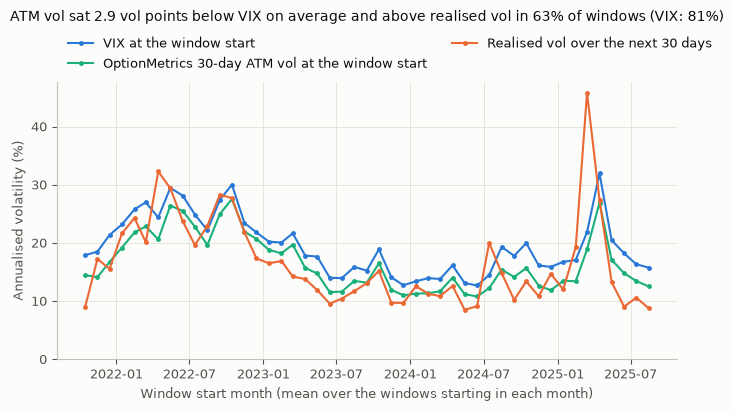

In [17]:
if om is not None:
    AQUA = "#1baf7a"  # third series colour after blue and orange
    dates_5c = start_dates[om_rows]
    share_5c = {label: np.mean(sig**2 * T0_5c > runs_5c[label].rv) for label, sig in sigma_5c.items()}
    gap_starts = sigma_5c["VIX"] - sigma_atm  # VIX minus ATM vol at the plotted window starts
    # Monthly means by window start month, so the chart shows no single day's OptionMetrics value.
    monthly = pd.DataFrame(
        {"VIX": sigma_5c["VIX"], "ATM": sigma_atm, "realised": sigma_r_5c}, index=dates_5c
    ).groupby(dates_5c.to_period("M")).mean()
    mid_month = monthly.index.to_timestamp() + pd.Timedelta(days=14)
    print(f"Figure 7b: monthly means over {len(monthly)} window start months, {monthly.index[0]} to {monthly.index[-1]}")
    print(f"Mean VIX minus ATM vol over the {dates_5c.size} window starts: {100 * gap_starts.mean():.2f} vol points")

    fig, ax = plt.subplots(figsize=(8, 3.6))
    for column, colour, label in (
        ("VIX", BLUE, "VIX at the window start"),
        ("ATM", AQUA, "OptionMetrics 30-day ATM vol at the window start"),
        ("realised", ORANGE, "Realised vol over the next 30 days"),
    ):
        ax.plot(mid_month, 100 * monthly[column], color=colour, lw=1.5, marker="o", ms=2.5, label=label)
    ax.set_xlabel("Window start month (mean over the windows starting in each month)")
    ax.set_ylabel("Annualised volatility (%)")
    ax.set_ylim(bottom=0)
    ax.set_title(
        f"ATM vol sat {100 * gap_starts.mean():.1f} vol points below VIX on average and above realised vol "
        f"in {share_5c['OptionMetrics ATM']:.0%} of windows (VIX: {share_5c['VIX']:.0%})",
        pad=44,
    )
    ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=2)
    save(fig, "fig7b_vix_atm_vs_realised_vol.png")
    plt.show()

## Stage 2b: Chain cleaning and implied forwards

Clean the option chain, fit parity forwards, and apply filters; produce Table 1.

## Stage 2c: Implied volatility extraction

Solve for implied vols via Brent's method; produce Figure 1.

## Stage 3: SVI calibration

Fit SVI smiles to each expiry slice; produce Figure 2 and Table 2.

## Stage 4: Arbitrage checks and variance-swap bridge

Check butterfly and calendar arbitrage, refit if needed, and build the variance-swap bridge; produce Figures 3 to 5 and Table 3.

## Stage 6: Write-up and reproducibility

Finalise README, verify fresh-install reproducibility, and tag v1.0.